# The stochastic O&M tool for down side risk in TIMES

## How to use
In your environment run 'pip install -e' to install the packages and dependensies

Then having the 'offshore_om' package you can import the nesessary functions and start.

In [1]:
from pathlib import Path

from offshore_om import run_master
from offshore_om import run_subsidy_capex
from offshore_om import load_scenario_configs

With the right depensesie intialise and cofigure your senario as you want with the right sensetivities and data
## Path configurations

In [2]:
# Root folder for the project. Update this if your workspace moves.
ROOT_DIR = Path(
    "C:/Users/IFE13253/OneDrive - Institutt for Energiteknikk/Documents/offshore-wind-om"
)

ROOT_DIR = Path(
    "/Users/aziah/IFE-work/pre-processing"
)


#Input and output folders
TIMES_INPUT_DIR = ROOT_DIR / "times-input"
OUTPUT_DIR = ROOT_DIR / "model-results"

Having cofigured the main paths you can configure the scenarios and the corresponding files from the input
## Scenario configuration
Her is an exemple with the inc and tech scenarios

In [3]:
# Scenario definitions for the master simulation.
# The Master script will read these files and optionally use market prices.
SCENARIO_CONFIGS = [
    {
        "Scenario": "TECH market",
        "MarketFile": TIMES_INPUT_DIR / "tech" / "tech onshore shadow price.csv",
        "production_folder": TIMES_INPUT_DIR / "tech",
        "market_price_file": TIMES_INPUT_DIR / "tech" / "tech_price.csv",
        "capacity_file": TIMES_INPUT_DIR / "tech" / "tech_capacity.csv",
    },
    {
        "Scenario": "INC market",
        "MarketFile": TIMES_INPUT_DIR / "inc" / "inc onshore shadow price.csv",
        "production_folder": TIMES_INPUT_DIR / "inc",
        "market_price_file": TIMES_INPUT_DIR / "inc" / "inc_price.csv",
        "capacity_file": TIMES_INPUT_DIR / "inc" / "inc_capacity.csv",
    },
]

print(ROOT_DIR)

/Users/aziah/IFE-work/pre-processing


In [4]:
# TIMES subsidy input and output configuration.
# This config only contains folder/file locations and mappings.
# Discount rates and base year are global and are not set here.
TIMES_SUBSIDY_CONFIG = {
    "region_price_map": {
        "O_Sorvest": "NO2",
        "O_Vestavind2": "NO2",
        "O_Nordvest": "NO3",
        "O_Nordavind": "NO4",
        "O_Vestavind1": "NO5",
    },
    "file_pattern": "*.csv",
    "process_filter": None,
}

Having the different scenarios you want to model import the sensitivities
## Sensetivity lists

In [5]:
# Sensitivity lists to sweep in the master simulation.
DISCOUNT_RATE_LIST = [0.07]  # e.g. [0.06, 0.07, 0.08]
TURBINE_CAPACITY_LIST = [15]  # e.g. [12, 15, 17, 20]
N_TURBINES_LIST = [1, 5, 10, 20, 35, 50, 75, 100]
HORIZON_YEARS = [25.0]  # e.g. [20.0, 25.0, 30.0]
FAILURE_RATE_TYPES = ["hendriks"]  # e.g. ["carrol", "hendriks"]
SUBSIDY_PRICE_LIST = [115]

base_year = 2030

total_runs = (len(DISCOUNT_RATE_LIST) * len(TURBINE_CAPACITY_LIST) * len(N_TURBINES_LIST) * len(HORIZON_YEARS) * len(FAILURE_RATE_TYPES) * len(SUBSIDY_PRICE_LIST) * len(SCENARIO_CONFIGS))

print(total_runs)

16


## Master table execution
Excecution of the montecarlo simulation and financial logic excecuted for all the sensitivites etc

Simulating for region: Nordavind

Completed simulation 1/1000
Campaigns: 3
Repairs: 3

Completed simulation 1000/1000
Campaigns: 4
Repairs: 4

SIMULATION SUMMARY
Mean Campaigns: 1.908
Mean direct cost: 179153.05693912748
Mean lost MWh: 24983.78268954835
Installed capacity: 15
Mean downtime per turbine: 3371.6305923816935

AVERAGE REPAIRS PER TURBINE OVER HORIZON
Gearbox   0.504 repairs/lifetime
Blades    1.337 repairs/lifetime
Generator 0.067 repairs/lifetime
Runnig discount rate 0.07
Figure exported to: /Users/aziah/IFE-work/pre-processing/notebooks/figures/cumulative_direct_cost_risk_evolution_Nordavind.pdf

Completed simulation 1/1000
Campaigns: 7
Repairs: 8

Completed simulation 1000/1000
Campaigns: 8
Repairs: 8

SIMULATION SUMMARY
Mean Campaigns: 8.916
Mean direct cost: 864579.6426121299
Mean lost MWh: 121264.48409100356
Installed capacity: 75
Mean downtime per turbine: 3272.9955220243874

AVERAGE REPAIRS PER TURBINE OVER HORIZON
Blades    1.305 repairs/lifetime
Gearbox   0.502 re

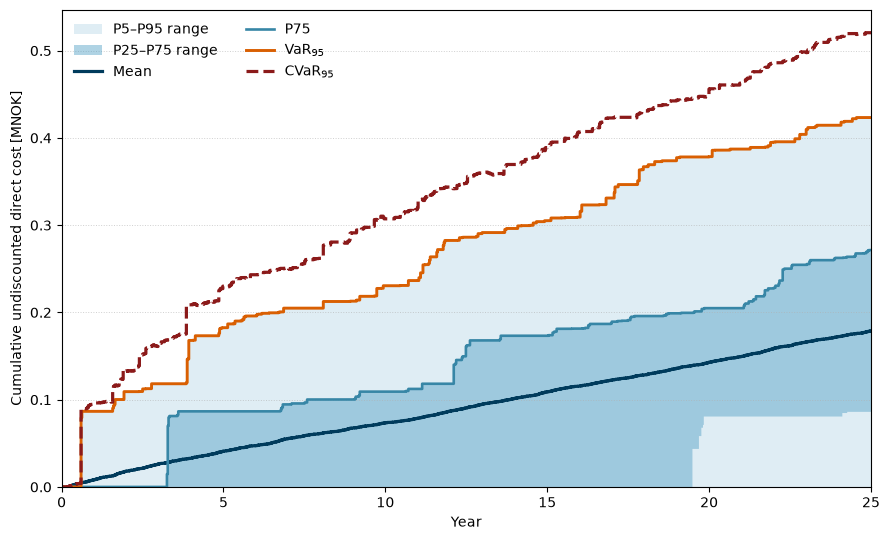

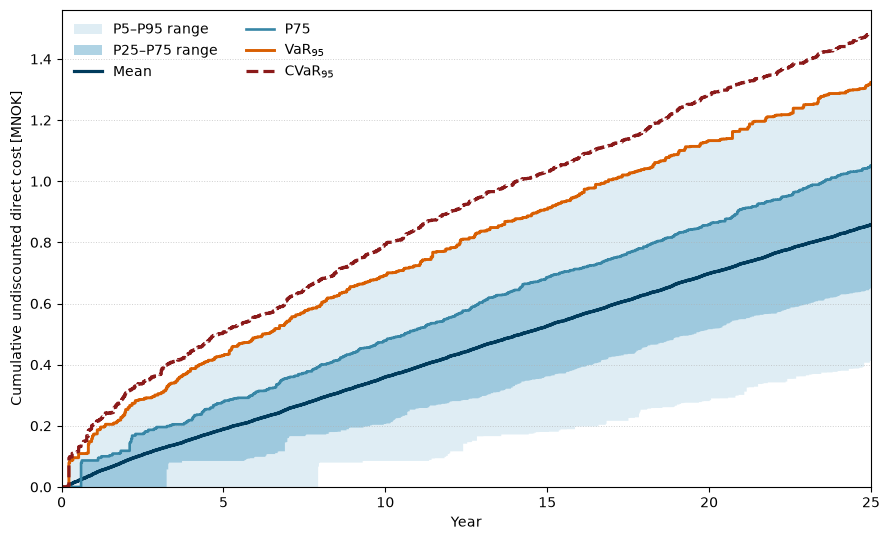

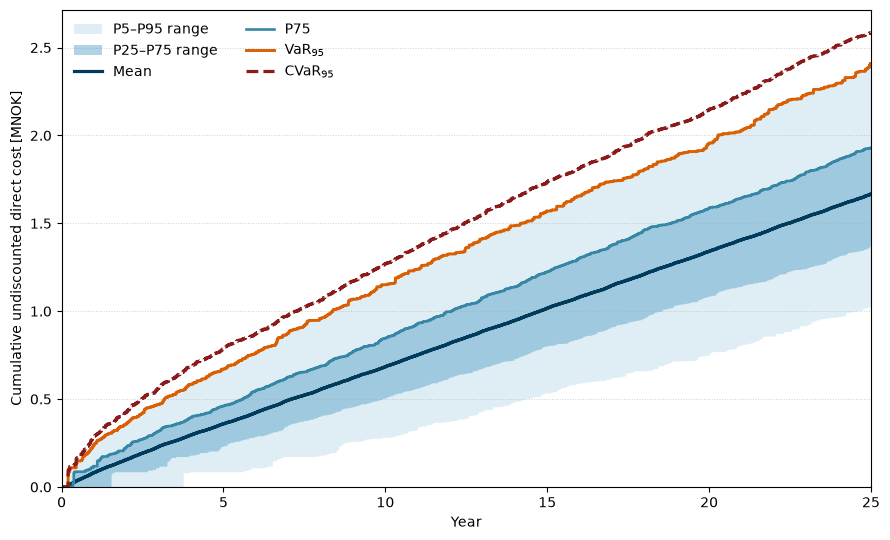

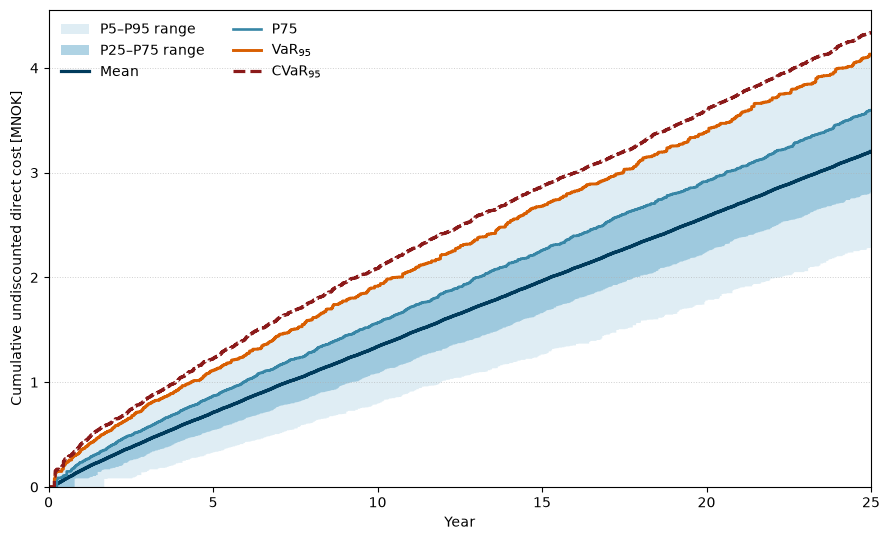

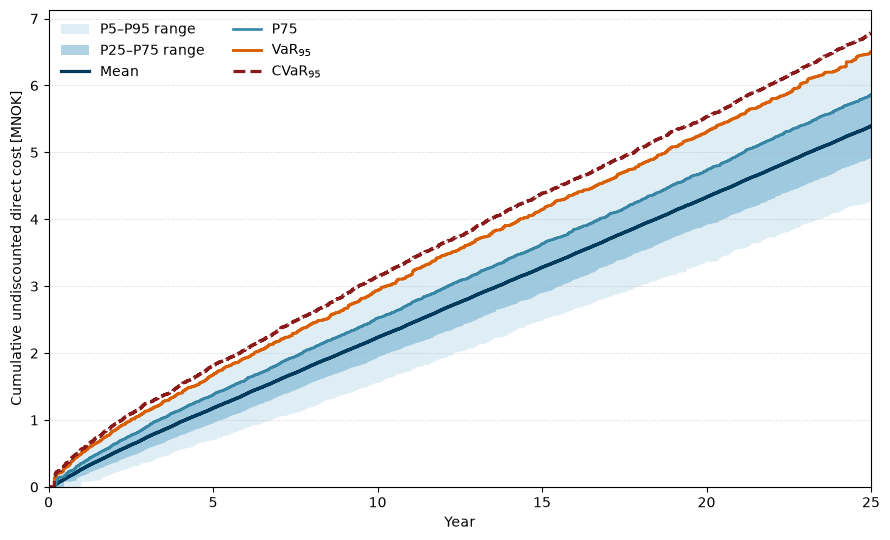

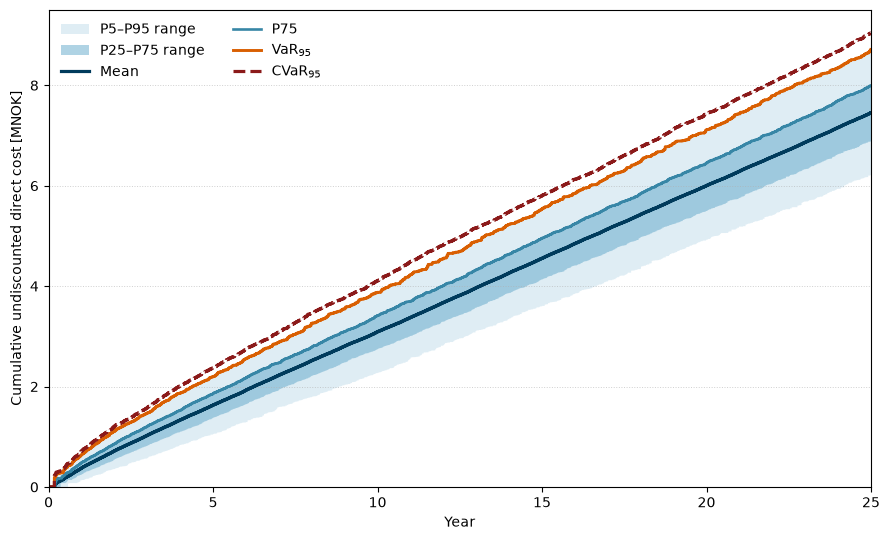

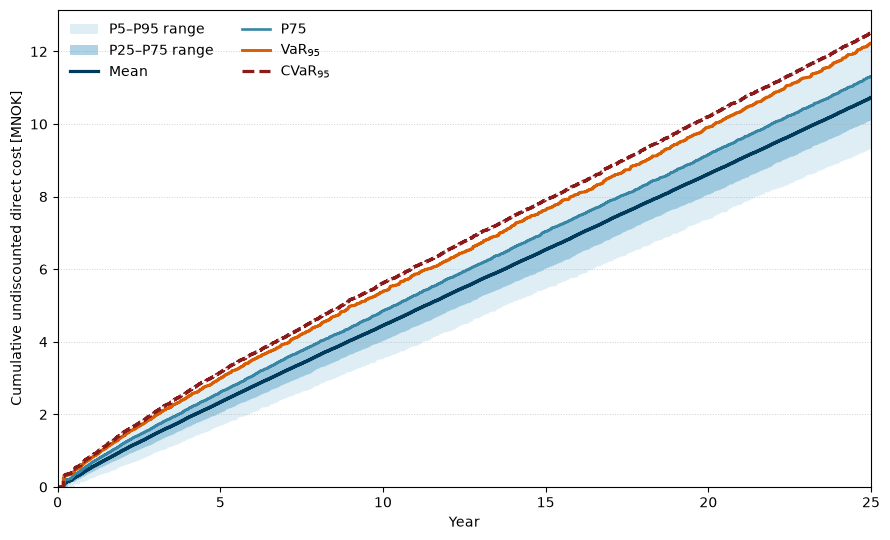

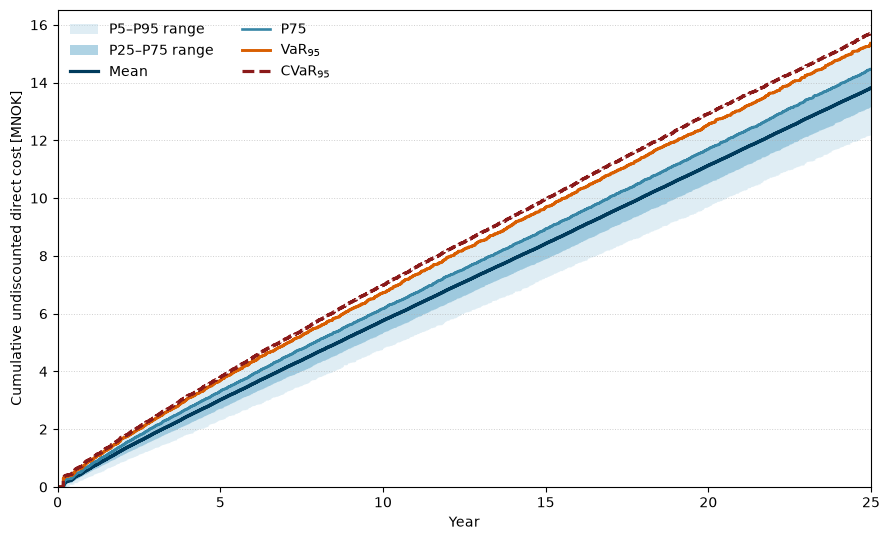

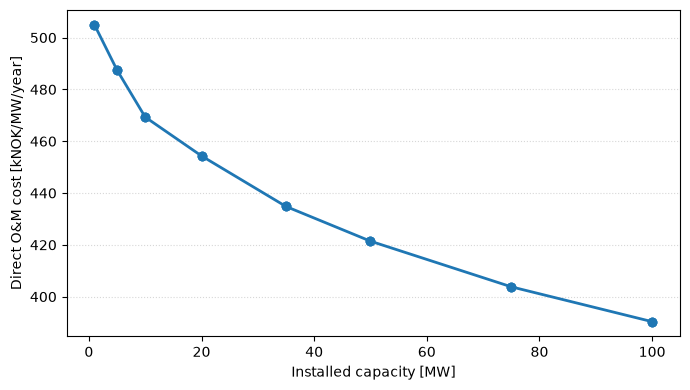

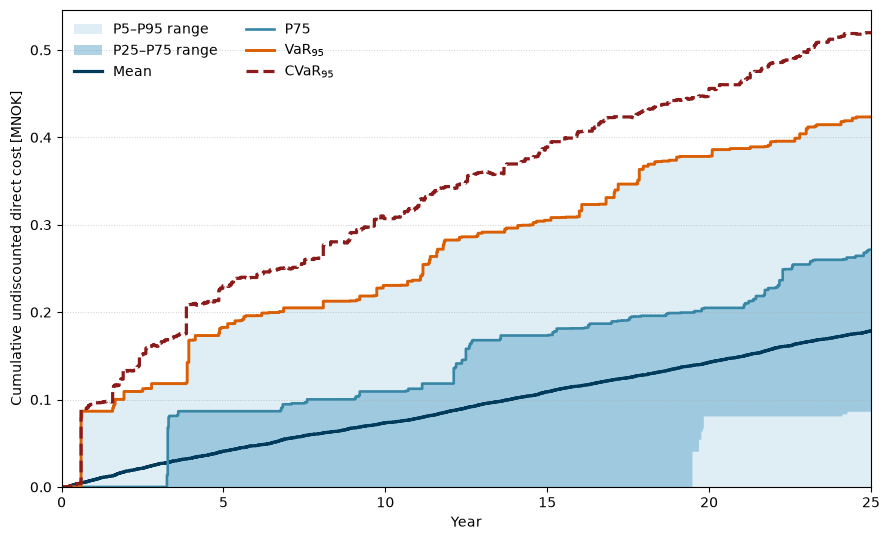

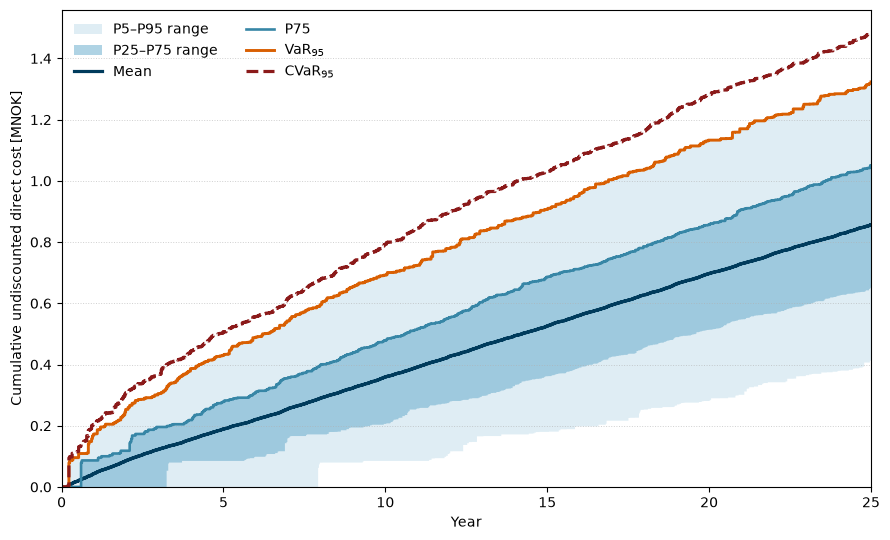

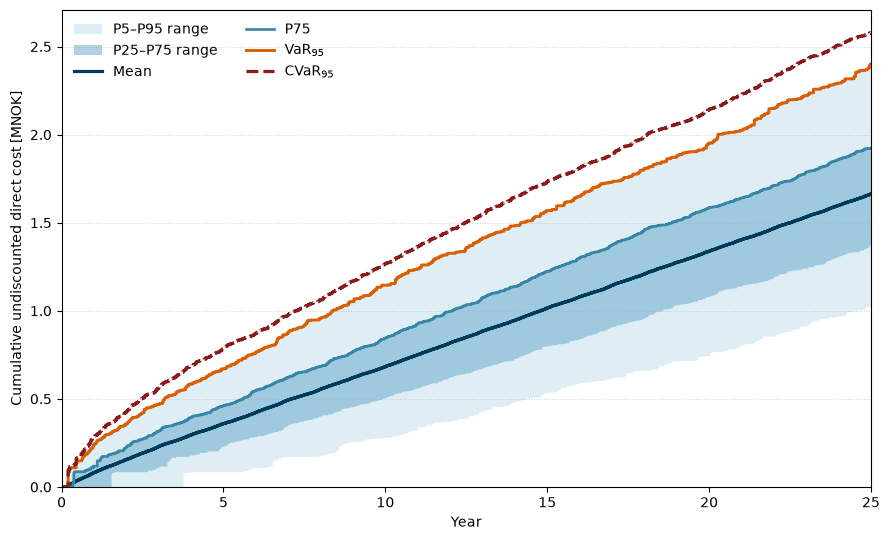

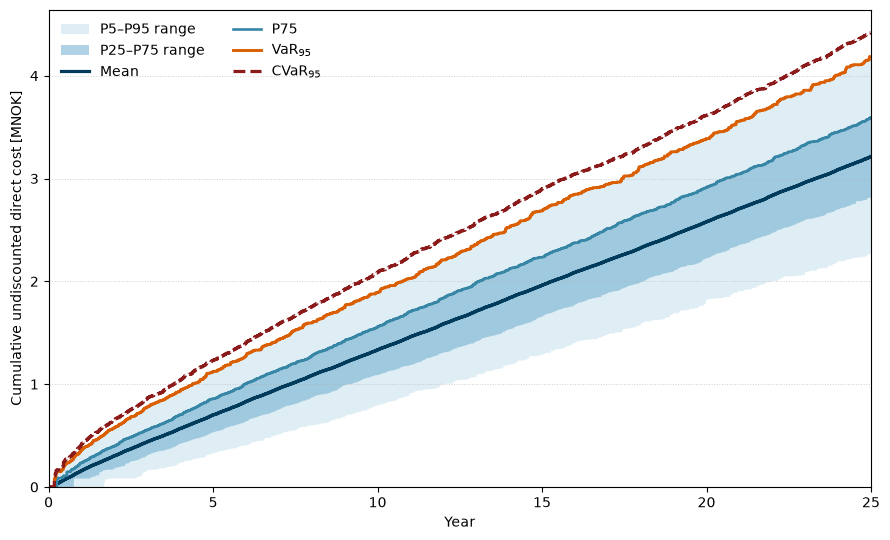

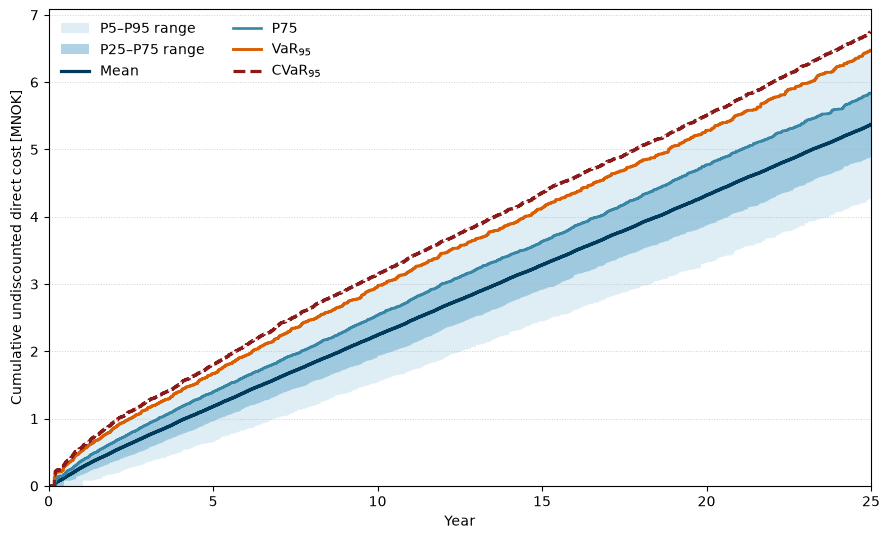

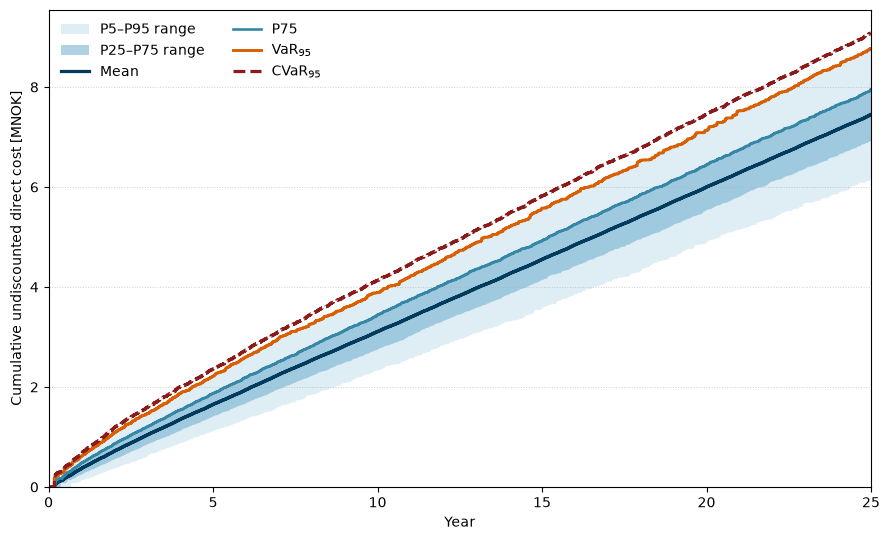

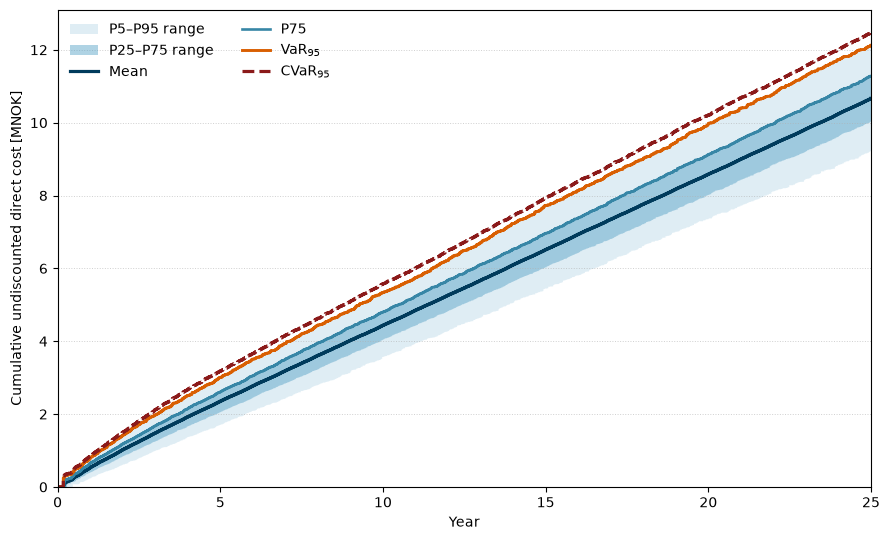

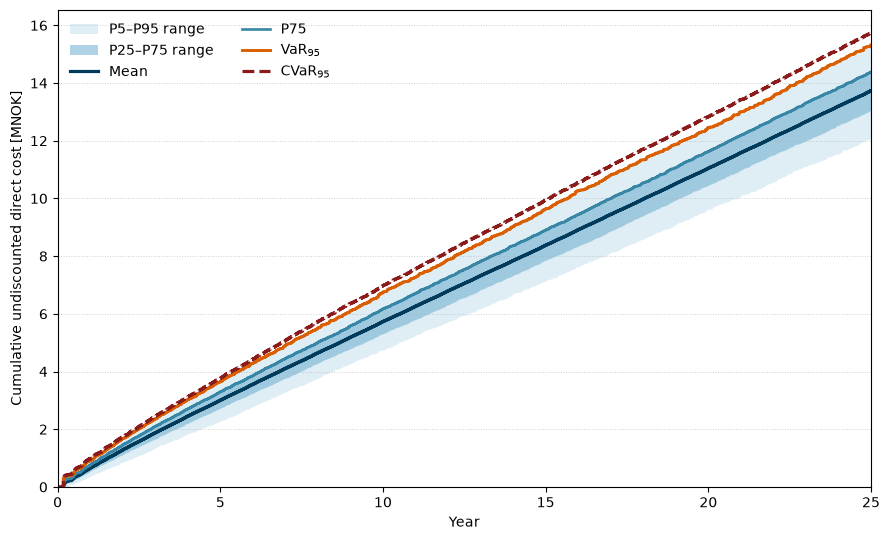

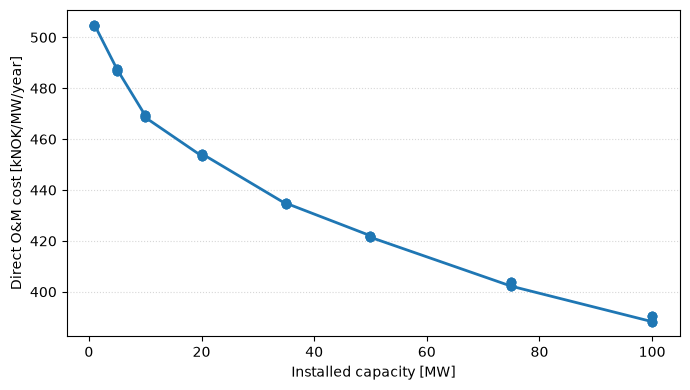

In [6]:
master_df = run_master(
    scenario_configs=load_scenario_configs(SCENARIO_CONFIGS),
    turbine_capacity_list=TURBINE_CAPACITY_LIST,
    n_turbines_list=N_TURBINES_LIST,
    discount_rate_list=DISCOUNT_RATE_LIST,
    horizon_years=HORIZON_YEARS,
    failure_rate_types=FAILURE_RATE_TYPES,
    subsidy_price_list=SUBSIDY_PRICE_LIST,
    output_dir=OUTPUT_DIR,
)



## TIMES subsidy representation
This is the output to represent subsidy gains in TIMES

In [6]:
times_capex_df = run_subsidy_capex(
    times_subsidy_config=TIMES_SUBSIDY_CONFIG,
    discount_rate_list=DISCOUNT_RATE_LIST,
    subsidy_price_list=SUBSIDY_PRICE_LIST,
    times_scenario=SCENARIO_CONFIGS,
    base_year = base_year,
    output_dir=OUTPUT_DIR,
)